In [ ]:
using LinearAlgebra
using Statistics
using Printf
using Plots

gr()  

default(size=(1100, 520), margin=6Plots.mm, grid=true)

In [ ]:
X_LO = 0.0
X_HI = 8.0

f1(x) = 5 - 24x + 17x^2 - (11/3)*x^3 + (1/4)*x^4

f2(x) = 5 - 24*(X_HI - x) + 17*(X_HI - x)^2 - (11/3)*(X_HI - x)^3 + (1/4)*(X_HI - x)^4

N_GRID = 2000
xgrid = collect(range(X_LO, X_HI, length=N_GRID))

f1_vals = f1.(xgrid)
f2_vals = f2.(xgrid)


2000-element Vector{Float64}:
 47.66666666666674
 47.442954733253146
 47.22004193483963
 46.99792660723574
 46.776607087790694
 46.55608171539302
 46.33634883046989
 46.11740677498801
 45.89925389245252
 45.6818885279082
 45.46530902793859
 45.24951374066643
 45.034501015753335
  ⋮
  3.9761048011545475
  4.066512602556194
  4.157450924307002
  4.248921161899889
  4.34092471236684
  4.433462974278862
  4.526537347746094
  4.620149234417755
  4.714300037482075
  4.808991161666424
  4.904224013237246
  5.0

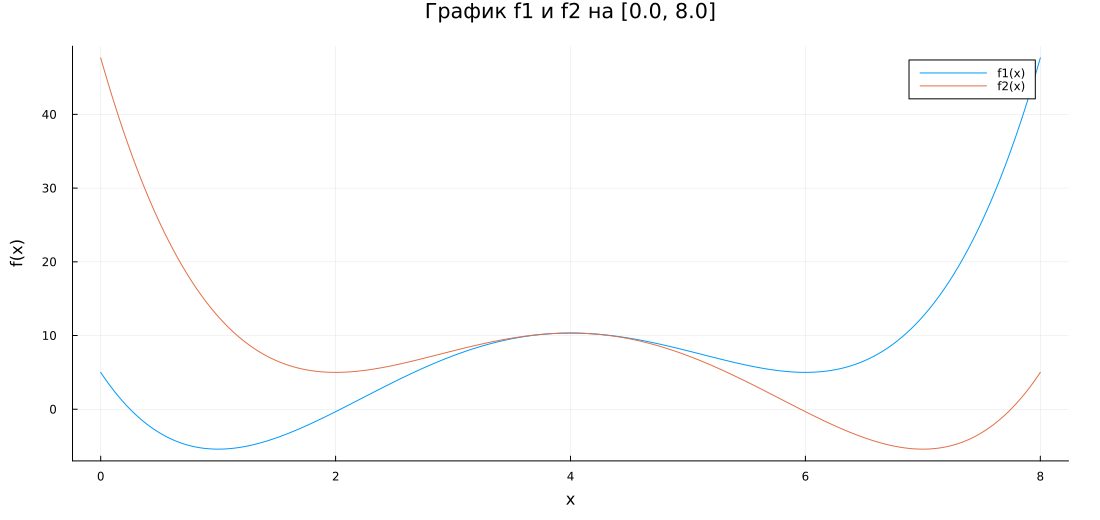

In [ ]:
p1 = plot(xgrid, f1_vals, label="f1(x)", xlabel="x", ylabel="f(x)", title="График f1 и f2 на [$(X_LO), $(X_HI)]")
plot!(p1, xgrid, f2_vals, label="f2(x)")
display(p1)


In [ ]:
function argmin_on_grid(vals)
    i = argmin(vals)
    return (xgrid[i], vals[i], i)
end

x1_star, f1_star, i1 = argmin_on_grid(f1_vals)
x2_star, f2_star, i2 = argmin_on_grid(f2_vals)

@printf("x1* = %.6f, f1* = %.8f\n", x1_star, f1_star)
@printf("x2* = %.6f, f2* = %.8f\n", x2_star, f2_star)

F_star = (f1_star, f2_star)

x1* = 1.000500, f1* = -5.41666479
x2* = 6.999500, f2* = -5.41666479


(-5.416664790124076, -5.416664790124076)

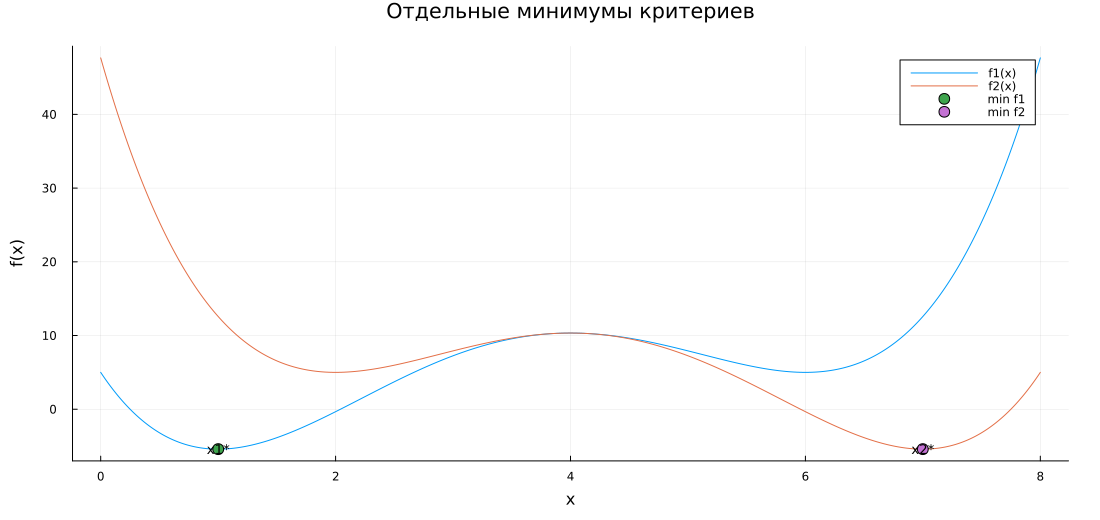

In [ ]:
p2 = plot(xgrid, f1_vals, label="f1(x)", xlabel="x", ylabel="f(x)", title="Отдельные минимумы критериев")
plot!(p2, xgrid, f2_vals, label="f2(x)")

scatter!(p2, [x1_star], [f1_star], label="min f1", markersize=6)
scatter!(p2, [x2_star], [f2_star], label="min f2", markersize=6)

annotate!(p2, x1_star, f1_star, text("x1*", 9))
annotate!(p2, x2_star, f2_star, text("x2*", 9))

display(p2)


In [ ]:
@inline function dominates(a1, a2, b1, b2)
    return (a1 <= b1) && (a2 <= b2) && ((a1 < b1) || (a2 < b2))
end

function pareto_mask(f1v, f2v)
    n = length(f1v)
    mask = trues(n)
    for i in 1:n
        if !mask[i]
            continue
        end
        for j in 1:n
            if i == j
                continue
            end
            if dominates(f1v[j], f2v[j], f1v[i], f2v[i])
                mask[i] = false
                break
            end
        end
    end
    return mask
end

pmask = pareto_mask(f1_vals, f2_vals)
pareto_x = xgrid[pmask]
pareto_f1 = f1_vals[pmask]
pareto_f2 = f2_vals[pmask]


ord = sortperm(pareto_x)
pareto_x = pareto_x[ord]
pareto_f1 = pareto_f1[ord]
pareto_f2 = pareto_f2[ord]

step_x = (X_HI - X_LO) / (N_GRID - 1)
gap_th = 3 * step_x
pareto_f1_line = Float64[]
pareto_f2_line = Float64[]
for k in 1:length(pareto_x)
    if k > 1 && (pareto_x[k] - pareto_x[k-1]) > gap_th
        push!(pareto_f1_line, NaN)
        push!(pareto_f2_line, NaN)
    end
    push!(pareto_f1_line, pareto_f1[k])
    push!(pareto_f2_line, pareto_f2[k])
end

@printf("Pareto points (grid) = %d\n", length(pareto_x))


Pareto points (grid) = 502


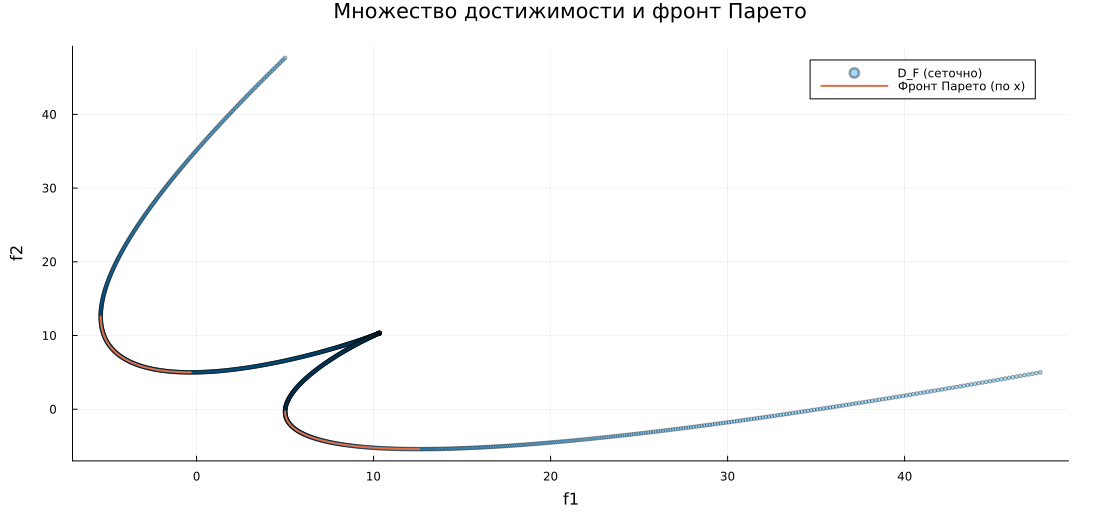

In [ ]:
p3 = scatter(f1_vals, f2_vals, ms=2, alpha=0.35, label="D_F (сеточно)",
    xlabel="f1", ylabel="f2", title="Множество достижимости и фронт Парето")
plot!(p3, pareto_f1_line, pareto_f2_line, lw=2, label="Фронт Парето (по x)")

display(p3)


In [ ]:
function phi_chebyshev(x, λ1, λ2, f1s, f2s)
    return max(λ1 * abs(f1(x) - f1s), λ2 * abs(f2(x) - f2s))
end


function golden_section_min(g, a, b; tol=1e-7, max_iter=120)
    ϕ = (sqrt(5) - 1) / 2  
    c = b - ϕ * (b - a)
    d = a + ϕ * (b - a)
    fc = g(c)
    fd = g(d)

    for _ in 1:max_iter
        if abs(b - a) < tol
            break
        end
        if fc < fd
            b = d
            d = c
            fd = fc
            c = b - ϕ * (b - a)
            fc = g(c)
        else
            a = c
            c = d
            fc = fd
            d = a + ϕ * (b - a)
            fd = g(d)
        end
    end

    xbest = (a + b) / 2
    return xbest, g(xbest)
end

function minimize_phi(λ1, λ2; pad=max(0.5, 0.05 * (X_HI - X_LO)))
    g(x) = phi_chebyshev(x, λ1, λ2, f1_star, f2_star)

    
    gvals = g.(xgrid)
    i0 = argmin(gvals)
    x0 = xgrid[i0]

    
    a = max(X_LO, x0 - pad)
    b = min(X_HI, x0 + pad)
    xhat, ghat = golden_section_min(g, a, b)

    return (xhat, ghat, (f1(xhat), f2(xhat)))
end


minimize_phi (generic function with 1 method)

In [ ]:
lambdas = [
    (0.4, 0.8),
    (0.8, 0.5),
    (0.3, 0.9)
]

sol_x = Float64[]
sol_f1 = Float64[]
sol_f2 = Float64[]

println("Решения метода идеальной точки:")
for (λ1, λ2) in lambdas
    xhat, ghat, (ff1, ff2) = minimize_phi(λ1, λ2)
    push!(sol_x, xhat)
    push!(sol_f1, ff1)
    push!(sol_f2, ff2)
    @printf("λ=(%.3f, %.3f) -> x̂=%.6f, f=(%.6f, %.6f), φ=%.8f\n", λ1, λ2, xhat, ff1, ff2, ghat)
end

Решения метода идеальной точки:
λ=(0.400, 0.800) -> x̂=6.000000, f=(5.000000, -0.333334), φ=4.16666592
λ=(0.800, 0.500) -> x̂=2.000000, f=(-0.333334, 5.000000), φ=5.20833240
λ=(0.300, 0.900) -> x̂=6.198997, f=(5.216778, -1.872184), φ=3.19003301


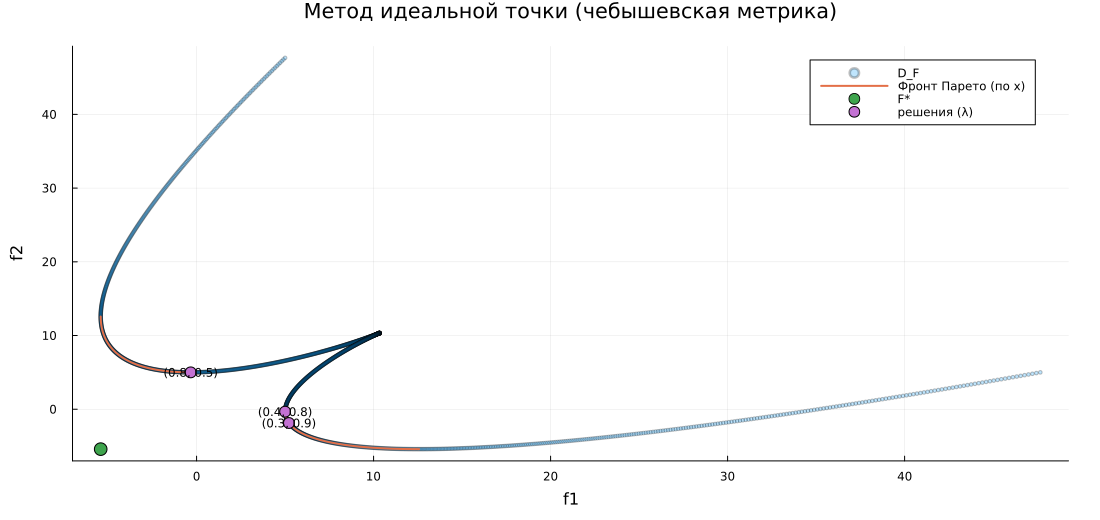

In [ ]:
p4 = scatter(f1_vals, f2_vals, ms=2, alpha=0.25, label="D_F", xlabel="f1", ylabel="f2",
    title="Метод идеальной точки (чебышевская метрика)")
plot!(p4, pareto_f1_line, pareto_f2_line, lw=2, label="Фронт Парето (по x)")

scatter!(p4, [f1_star], [f2_star], label="F*", markersize=7)

scatter!(p4, sol_f1, sol_f2, label="решения (λ)", markersize=6)

for k in 1:length(lambdas)
    λ1, λ2 = lambdas[k]
    annotate!(p4, sol_f1[k], sol_f2[k], text("($(round(λ1,digits=2)), $(round(λ2,digits=2)))", 8))
end

display(p4)

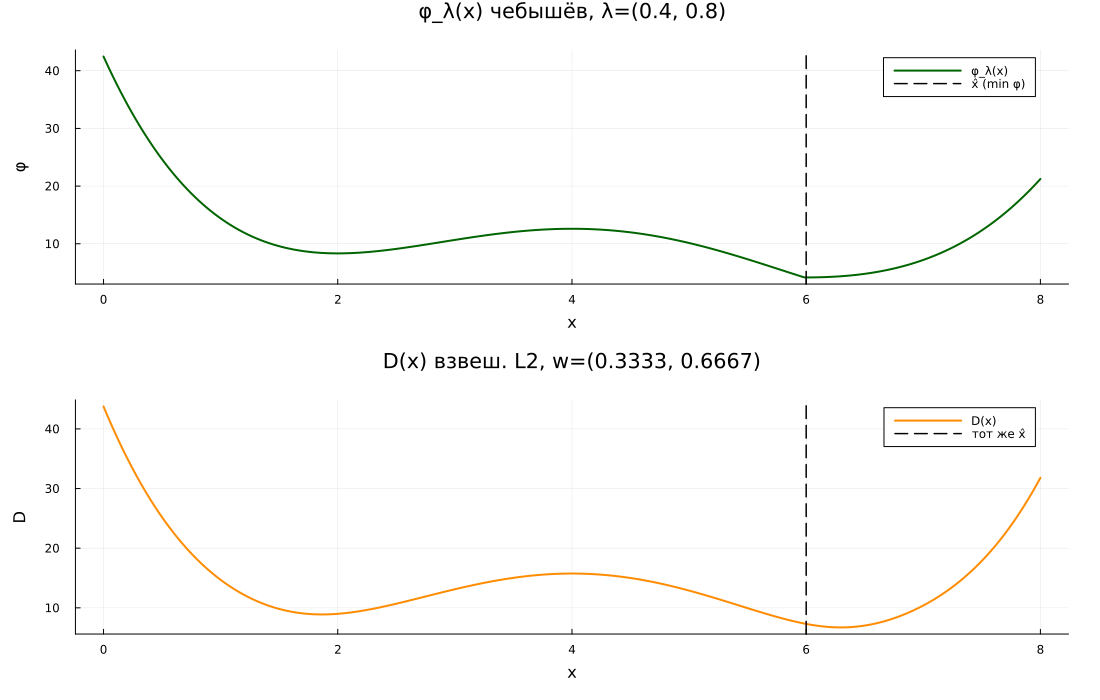

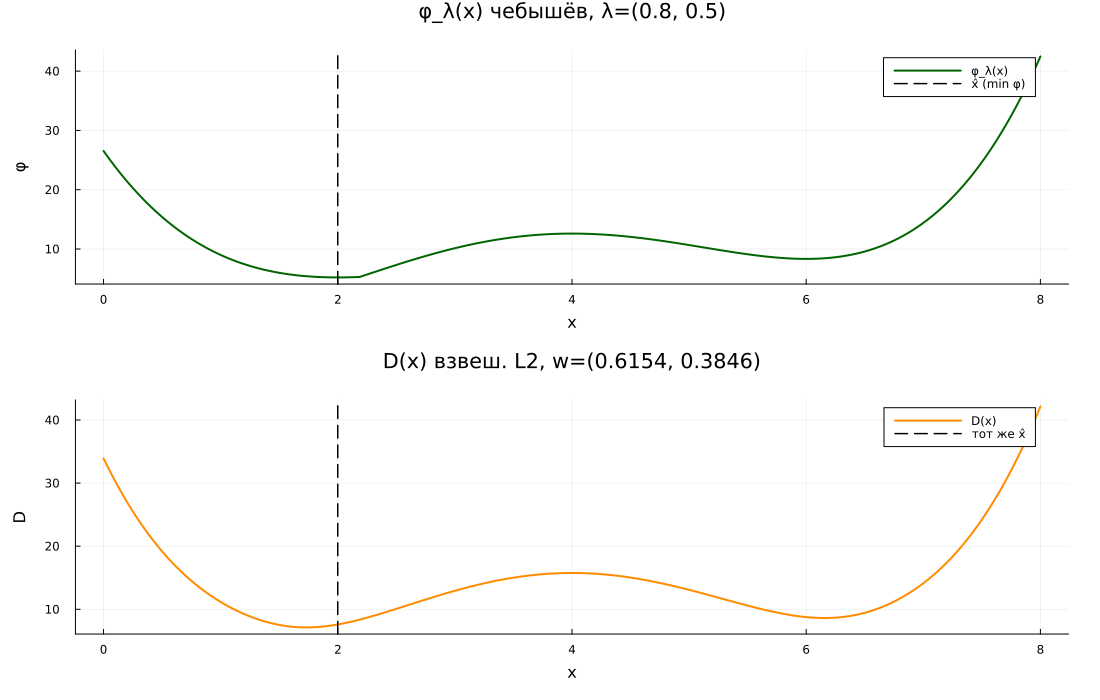

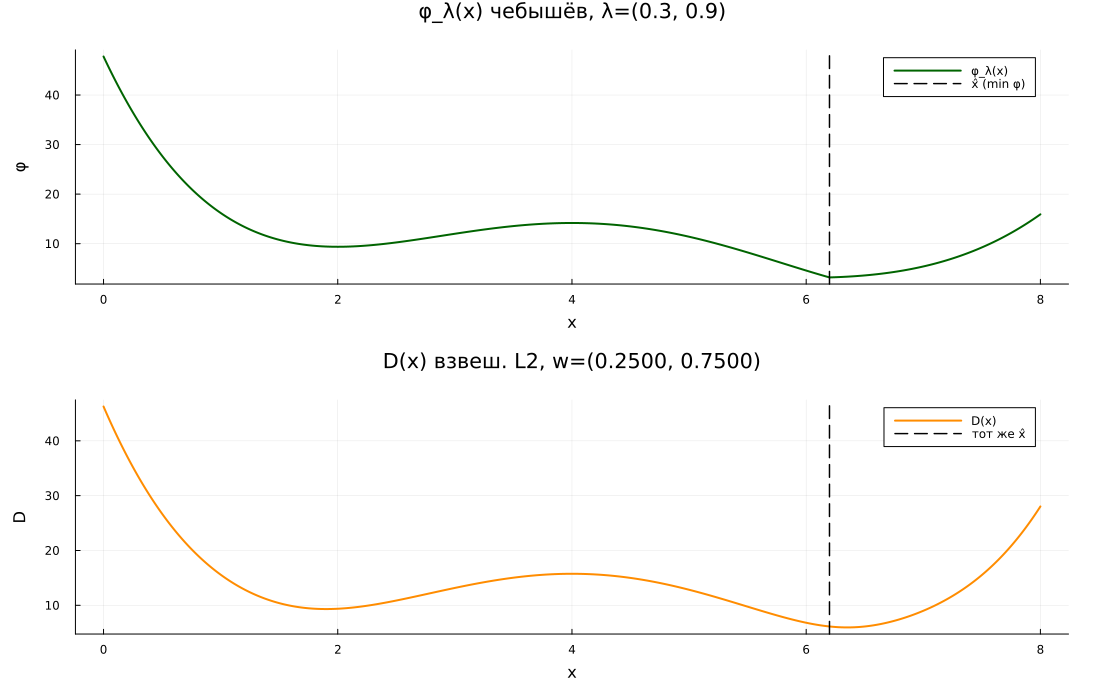

In [ ]:
function euclid_D(x, w1, w2)
    return sqrt(w1 * (f1(x) - f1_star)^2 + w2 * (f2(x) - f2_star)^2)
end

for k in eachindex(lambdas)
    λ1, λ2 = lambdas[k]
    s = λ1 + λ2
    if s <= 0
        error("λ должны быть > 0")
    end
    w1 = λ1 / s
    w2 = λ2 / s

    phi_line = [phi_chebyshev(x, λ1, λ2, f1_star, f2_star) for x in xgrid]
    D_line   = [euclid_D(x, w1, w2) for x in xgrid]

    t1 = @sprintf("φ_λ(x) чебышёв, λ=(%.4g, %.4g)", λ1, λ2)
    pA = plot(xgrid, phi_line; label="φ_λ(x)", color=:darkgreen, lw=2,
        title=t1, xlabel="x", ylabel="φ", legend=:topright)
    vline!(pA, [sol_x[k]]; label="x̂ (min φ)", color=:black, ls=:dash, lw=1.5)

    t2 = @sprintf("D(x) взвеш. L2, w=(%.4f, %.4f)", w1, w2)
    pB = plot(xgrid, D_line; label="D(x)", color=:darkorange, lw=2,
        title=t2, xlabel="x", ylabel="D", legend=:topright)
    vline!(pB, [sol_x[k]]; label="тот же x̂", color=:black, ls=:dash, lw=1.5)

    display(plot(pA, pB; layout=(2, 1), size=(1100, 700), margin=6Plots.mm))
end
